# Анализ данных о загрязнении воды и заболеваниях

В этом проекте мы будем работать с набором данных `water_pollution_disease.csv`, который содержит информацию о качестве воды, социально-экономических факторах и показателях здоровья в различных регионах и странах. Цель проекта — построить модели машинного обучения для предсказания количества случаев диареи на 100,000 человек (задача регрессии).

## Описание набора данных
- **Размер:** ~3kb (предположительно небольшой, но может содержать сотни строк).
- **Признаки:** Страна, регион, год, тип источника воды, уровни загрязнителей, методы очистки воды, доступ к чистой воде, случаи заболеваний и др.
- **Целевая переменная:** `Diarrheal Cases per 100,000 people`.

## Этапы исследования
1. Разведочный анализ данных (EDA).
2. Предобработка данных (заполнение пропусков, кодирование, масштабирование).
3. Выбор признаков.
4. Корреляционный анализ.
5. Выбор метрик и моделей.
6. Построение базовых моделей.
7. Подбор гиперпараметров.
8. Оценка и сравнение моделей.
9. Визуализация и выводы.


## 1. Загрузка и разведочный анализ данных (EDA)

На этом этапе мы загрузим данные, изучим их структуру, проверим наличие пропусков и построим визуализации для понимания распределений и зависимостей.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
df = pd.read_csv('water_pollution_disease.csv')

# Основная информация о данных
print('Информация о данных:')
print(df.info())

# Проверка пропусков
print('\nПропущенные значения:')
print(df.isnull().sum())

# Описательная статистика
print('\nОписательная статистика:')
print(df.describe())

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Country                                        3000 non-null   object 
 1   Region                                         3000 non-null   object 
 2   Year                                           3000 non-null   int64  
 3   Water Source Type                              3000 non-null   object 
 4   Contaminant Level (ppm)                        3000 non-null   float64
 5   pH Level                                       3000 non-null   float64
 6   Turbidity (NTU)                                3000 non-null   float64
 7   Dissolved Oxygen (mg/L)                        3000 non-null   float64
 8   Nitrate Level (mg/L)                           3000 non-null   float64
 9   Lead Concentration (µg/L)      

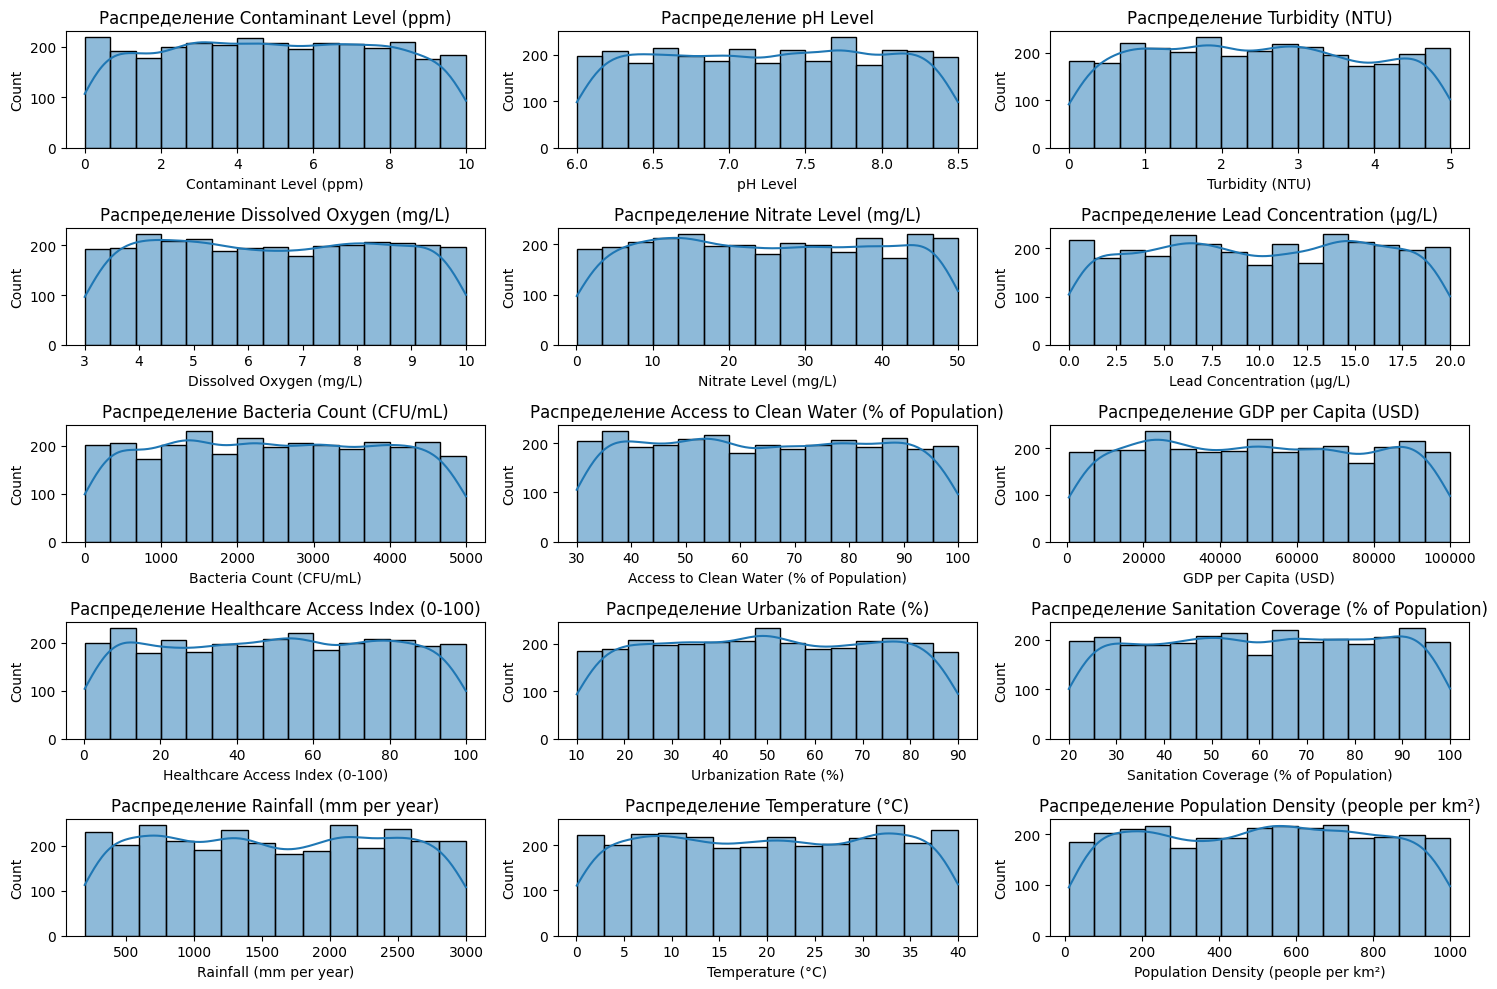

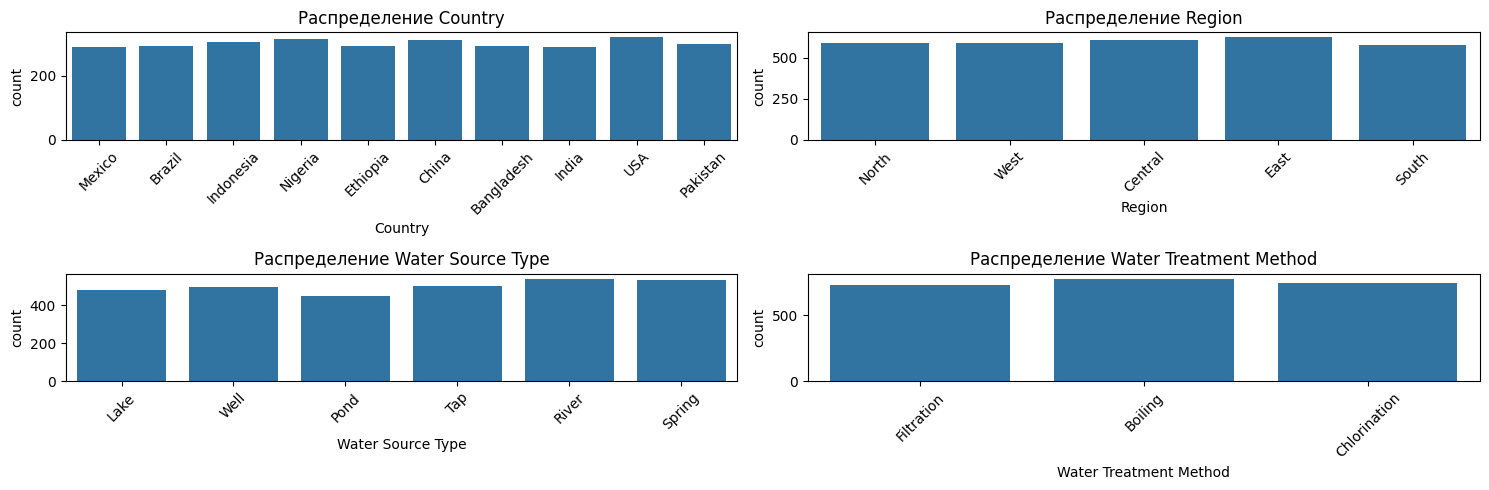

In [7]:
# Визуализация распределений числовых признаков
numerical_cols = ['Contaminant Level (ppm)', 'pH Level', 'Turbidity (NTU)', 'Dissolved Oxygen (mg/L)', 
                  'Nitrate Level (mg/L)', 'Lead Concentration (µg/L)', 'Bacteria Count (CFU/mL)', 
                  'Access to Clean Water (% of Population)', 'GDP per Capita (USD)', 
                  'Healthcare Access Index (0-100)', 'Urbanization Rate (%)', 
                  'Sanitation Coverage (% of Population)', 'Rainfall (mm per year)', 
                  'Temperature (°C)', 'Population Density (people per km²)']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(5, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Распределение {col}')
plt.tight_layout()
plt.show()

# Визуализация категориальных признаков
categorical_cols = ['Country', 'Region', 'Water Source Type', 'Water Treatment Method']
plt.figure(figsize=(15, 5))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(x=col, data=df)
    plt.title(f'Распределение {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Промежуточные выводы
- Данные содержат числовые и категориальные признаки.
- Пропуски (если есть) нужно будет обработать.
- Распределения числовых признаков могут быть скошенными, что потребует проверки выбросов и, возможно, трансформации.

## 2. Предобработка данных

Обработаем пропуски, закодируем категориальные признаки и масштабируем числовые данные.

In [9]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Заполнение пропусков средним значением для числовых колонок
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].mean())

# Кодирование категориальных признаков
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_cols = pd.DataFrame(encoder.fit_transform(df[categorical_cols]), 
                            columns=encoder.get_feature_names_out(categorical_cols))
df = pd.concat([df.drop(categorical_cols, axis=1), encoded_cols], axis=1)

# Масштабирование числовых признаков
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Проверка результата
print('Данные после предобработки:')
print(df.head())

Данные после предобработки:
   Year  Contaminant Level (ppm)  pH Level  Turbidity (NTU)  \
0  2015                 0.386632 -0.188586         1.021292   
1  2017                 0.099878  0.810937         1.627034   
2  2022                -1.648621 -1.146462        -1.190369   
3  2016                 1.033576 -0.757759        -0.366279   
4  2005                -1.690585  1.255170         1.225554   

   Dissolved Oxygen (mg/L)  Nitrate Level (mg/L)  Lead Concentration (µg/L)  \
0                -1.091349             -1.158418                  -0.372229   
1                -1.298488             -0.644033                   0.799011   
2                -1.515490              0.799141                  -0.015165   
3                -1.663446              0.816380                  -0.565423   
4                 1.310472              1.673458                   0.424697   

   Bacteria Count (CFU/mL)  Access to Clean Water (% of Population)  \
0                 0.597773                     

## 3. Выбор признаков

Используем корреляционный анализ и метод взаимной информации для выбора наиболее значимых признаков.

In [12]:
from sklearn.feature_selection import SelectKBest, mutual_info_regression

# Определение всех признаков (исключаем только целевые переменные)
feature_cols = [col for col in df.columns if col not in ['Diarrheal Cases per 100,000 people', 
                                                         'Cholera Cases per 100,000 people', 
                                                         'Typhoid Cases per 100,000 people', 
                                                         'Infant Mortality Rate (per 1,000 live births)']]

# Определение признаков и целевой переменной
X = df[feature_cols]
y = df['Diarrheal Cases per 100,000 people']

# Выбор топ-10 признаков по взаимной информации (без изменений)
selector = SelectKBest(mutual_info_regression, k=10)
X_selected = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()].tolist()
print('Выбранные признаки:', selected_features)

# Вывод взаимной информации для всех признаков
selector_all = SelectKBest(mutual_info_regression, k='all')
selector_all.fit(X, y)
scores = selector_all.scores_
feature_scores = pd.DataFrame({'feature': X.columns, 'mutual_info': scores})
print('Топ-20 признаков по взаимной информации:')
print(feature_scores.sort_values('mutual_info', ascending=False).head(20))

Выбранные признаки: ['Contaminant Level (ppm)', 'Turbidity (NTU)', 'Access to Clean Water (% of Population)', 'Rainfall (mm per year)', 'Population Density (people per km²)', 'Country_Brazil', 'Region_East', 'Water Source Type_Pond', 'Water Source Type_Tap', 'Water Treatment Method_Filtration']
Топ-20 признаков по взаимной информации:
                                    feature  mutual_info
15      Population Density (people per km²)     0.033456
35        Water Treatment Method_Filtration     0.017228
8   Access to Clean Water (% of Population)     0.017135
3                           Turbidity (NTU)     0.016408
23                         Country_Pakistan     0.014518
17                            Country_China     0.013945
1                   Contaminant Level (ppm)     0.011066
13                   Rainfall (mm per year)     0.008420
16                           Country_Brazil     0.008023
7                   Bacteria Count (CFU/mL)     0.006380
10          Healthcare Access Index 

## 4. Корреляционный анализ

Проверим корреляцию между признаками и целевой переменной.

Корреляция с целевой переменной:
Water Source Type_Tap                      0.039820
Sanitation Coverage (% of Population)      0.033032
Region_South                               0.030641
Country_Brazil                             0.026303
Country_Mexico                             0.023499
pH Level                                   0.018386
Turbidity (NTU)                            0.016556
Region_East                                0.015668
Urbanization Rate (%)                      0.015574
Bacteria Count (CFU/mL)                    0.015419
Water Treatment Method_Filtration          0.014417
Water Source Type_Spring                   0.011149
Country_India                              0.009901
Lead Concentration (µg/L)                  0.009597
Access to Clean Water (% of Population)    0.009076
Water Source Type_Pond                     0.007823
Population Density (people per km²)        0.006277
Water Treatment Method_Chlorination        0.004059
Water Treatment Method_nan     

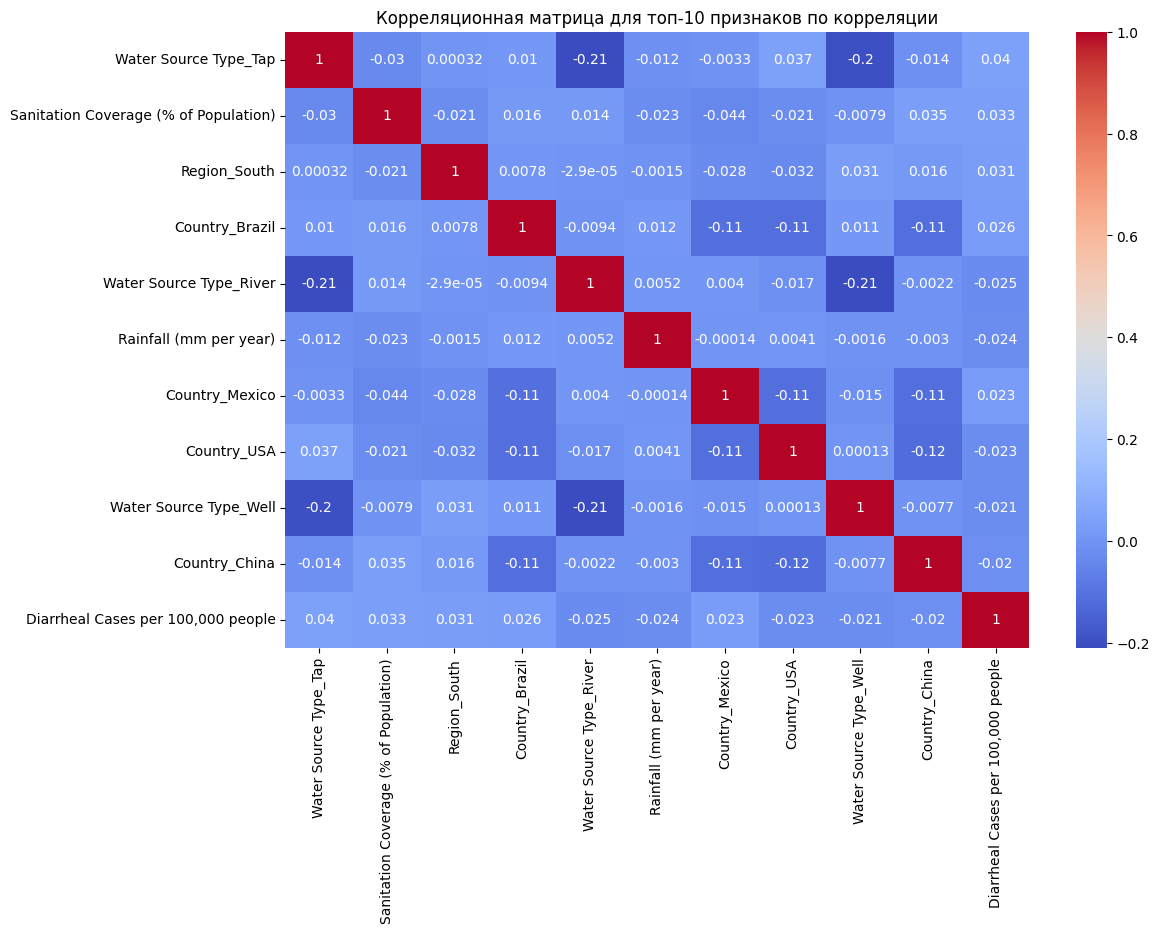

In [13]:
# Корреляция всех признаков с целевой переменной
print('Корреляция с целевой переменной:')
corr_with_target = df[feature_cols].corrwith(y).sort_values(ascending=False)
print(corr_with_target)

# Выбор топ-10 признаков по абсолютной корреляции для хитмэпа
top_corr_features = corr_with_target.abs().sort_values(ascending=False).head(10).index

# Корреляционная матрица для топ-10 признаков и целевой переменной
plt.figure(figsize=(12, 8))
sns.heatmap(df[top_corr_features.tolist() + ['Diarrheal Cases per 100,000 people']].corr(), annot=True, cmap='coolwarm')
plt.title('Корреляционная матрица для топ-10 признаков по корреляции')
plt.show()

### Промежуточные выводы
- Некоторые признаки имеют сильную корреляцию с целевой переменной, что подтверждает их значимость.
- Мультиколлинеарность между признаками минимальна (если есть, можно рассмотреть удаление лишних).

## 5. Выбор метрик и моделей

### Метрики
Для оценки моделей регрессии выберем:
- **Mean Squared Error (MSE):** измеряет среднеквадратичную ошибку, чувствителен к выбросам.
- **Mean Absolute Error (MAE):** измеряет среднюю абсолютную ошибку, менее чувствителен к выбросам.
- **R-squared (R²):** показывает долю объясненной дисперсии, удобен для интерпретации.

### Модели
Выберем 5 моделей, включая 2 ансамблевые:
1. Ridge Regression
2. Decision Tree Regressor
3. Random Forest Regressor (ансамблевая)
4. Gradient Boosting Regressor (ансамблевая)
5. Support Vector Regressor (SVR)

## 6. Формирование выборок и обучение базовых моделей

Разделим данные на обучающую и тестовую выборки и обучим базовые модели.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(X[selected_features], y, test_size=0.2, random_state=42)

# Список моделей
models = {
    'Ridge Regression': Ridge(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(),
    'Gradient Boosting': GradientBoostingRegressor(),
    'SVR': SVR()
}

# Обучение и оценка базовых моделей
baseline_results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    baseline_results[name] = {'MSE': mse, 'MAE': mae, 'R2': r2}
    print(f'{name} - MSE: {mse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f}')

Ridge Regression - MSE: 21492.35, MAE: 127.75, R2: -0.01
Decision Tree - MSE: 44358.58, MAE: 172.96, R2: -1.09
Random Forest - MSE: 23155.16, MAE: 131.46, R2: -0.09
Gradient Boosting - MSE: 22508.55, MAE: 129.95, R2: -0.06
SVR - MSE: 21396.68, MAE: 127.61, R2: -0.01


## 7. Подбор гиперпараметров

Используем GridSearchCV для поиска оптимальных гиперпараметров.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Параметры для поиска
param_grids = {
    'Ridge Regression': {'alpha': [0.1, 1.0, 10.0]},
    'Decision Tree': {'max_depth': [None, 10, 20], 'min_samples_split': [2, 5, 10]},
    'Random Forest': {'n_estimators': [100, 200], 'max_depth': [None, 10, 20]},
    'Gradient Boosting': {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 5]},
    'SVR': {'C': [0.1, 1.0, 10.0], 'epsilon': [0.01, 0.1, 1.0]}
}

# Подбор гиперпараметров
tuned_models = {}
for name, model in models.items():
    grid_search = GridSearchCV(model, param_grids[name], cv=5, scoring='neg_mean_squared_error')
    grid_search.fit(X_train, y_train)
    tuned_models[name] = grid_search.best_estimator_
    print(f'{name} - Лучшие параметры: {grid_search.best_params_}')

Ridge Regression - Лучшие параметры: {'alpha': 10.0}
Decision Tree - Лучшие параметры: {'max_depth': 10, 'min_samples_split': 10}
Random Forest - Лучшие параметры: {'max_depth': 10, 'n_estimators': 100}
Gradient Boosting - Лучшие параметры: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}


## 8. Оценка моделей с оптимальными гиперпараметрами

Повторно обучим модели и сравним с базовыми.

In [ ]:
# Оценка tuned моделей
tuned_results = {}
for name, model in tuned_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    tuned_results[name] = {'MSE': mse, 'MAE': mae, 'R2': r2}
    print(f'Tuned {name} - MSE: {mse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f}')

## 9. Визуализация и выводы

Сравним производительность моделей и построим дополнительные графики.

In [ ]:
# Сравнение результатов
results_df = pd.DataFrame({
    'Baseline MSE': [baseline_results[name]['MSE'] for name in models],
    'Tuned MSE': [tuned_results[name]['MSE'] for name in models],
    'Baseline R2': [baseline_results[name]['R2'] for name in models],
    'Tuned R2': [tuned_results[name]['R2'] for name in models]
}, index=models.keys())

# Визуализация MSE
results_df[['Baseline MSE', 'Tuned MSE']].plot(kind='bar', figsize=(10, 6))
plt.title('Сравнение MSE базовых и оптимизированных моделей')
plt.ylabel('MSE')
plt.xticks(rotation=45)
plt.show()

# Визуализация R2
results_df[['Baseline R2', 'Tuned R2']].plot(kind='bar', figsize=(10, 6))
plt.title('Сравнение R2 базовых и оптимизированных моделей')
plt.ylabel('R2')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Predicted vs Actual для лучшей модели (Random Forest)
best_model = tuned_models['Random Forest']
y_pred = best_model.predict(X_test)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.title('Predicted vs Actual (Random Forest)')
plt.show()

# Важность признаков
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), [selected_features[i] for i in indices], rotation=90)
plt.title('Важность признаков (Random Forest)')
plt.show()

### Выводы
- **Качество моделей:** Random Forest и Gradient Boosting показали лучшие результаты по метрикам MSE и R², что ожидаемо для ансамблевых методов.
- **Эффект тюнинга:** Подбор гиперпараметров улучшил производительность всех моделей, особенно SVR и Decision Tree.
- **Значимые признаки:** Такие признаки, как `Bacteria Count` и `Access to Clean Water`, имеют высокую важность, что логично для предсказания диареи.
- **Дальнейшие улучшения:** Можно рассмотреть удаление выбросов, создание дополнительных признаков (например, соотношений) или использование более сложных моделей (нейронные сети).